In [1]:
"""
Symulacja trajektorii cen aktywa w modelach GBM i Hestona.

Modele:
    GBM:    dS_t = mu * S_t dt + sigma * S_t dW_t
    Heston: dS_t = r  * S_t dt + sqrt(v_t) * S_t dW_t^(1)
            dv_t = kappa * (theta - v_t) dt + xi * sqrt(v_t) dW_t^(2)
            corr(dW^(1), dW^(2)) = rho

Schematy dyskretyzacyjne:
    GBM:    log-Euler (DOKŁADNY dla dowolnego dt, brak błędu dyskretyzacji,
            ponieważ rozwiązanie GBM ma postać zamkniętą).
    Heston: Full Truncation Euler (Andersen 2008) — najpopularniejszy
            prosty schemat radzący sobie z problemem ujemnej wariancji.
"""

import numpy as np


# =============================================================================
# Parametry wspólne
# =============================================================================
S0 = 100.0          # cena początkowa aktywa
T = 1.0             # horyzont czasowy w latach
M = 252             # liczba kroków czasowych (dni handlowe w roku)
N = 20              # liczba trajektorii do wizualizacji
r = 0.03            # stopa wolna od ryzyka
dt = T / M
t_grid = np.linspace(0.0, T, M + 1)

# Wspólny generator dla powtarzalności wyników
rng = np.random.default_rng(seed=42)


# =============================================================================
# Model 1: Geometryczny Ruch Browna (GBM)
# =============================================================================
mu_gbm = 0.08       # dryf (miara fizyczna P, nie miara martyngałowa Q)
sigma_gbm = 0.17    # zmienność

# Próbka iid N(0,1) o kształcie (N, M)
Z = rng.standard_normal(size=(N, M))

# Schemat log-Eulera: log S_{k+1} = log S_k + (mu - sigma^2/2) dt + sigma sqrt(dt) Z
log_increments = (mu_gbm - 0.5 * sigma_gbm**2) * dt + sigma_gbm * np.sqrt(dt) * Z
log_paths = np.log(S0) + np.cumsum(log_increments, axis=1)
log_paths = np.concatenate([np.full((N, 1), np.log(S0)), log_paths], axis=1)
S_gbm = np.exp(log_paths)  # kształt (N, M+1)


# =============================================================================
# Model 2: Heston (stochastyczna zmienność)
# =============================================================================
v0 = 0.04           # wariancja początkowa
theta = 0.05        # długoterminowa wariancja (mean-reversion level)
kappa = 3.5         # szybkość powrotu do średniej
xi = 0.20           # zmienność wariancji (vol of vol)
rho = -0.7          # korelacja między ruchem ceny a ruchem wariancji

# Sprawdzenie warunku Fellera 2 kappa theta > xi^2
# (gwarantuje dodatniość v_t w sensie ciągłym; w schemacie dyskretnym i tak
#  potrzebny jest mechanizm zabezpieczający — tu Full Truncation)
feller_lhs = 2.0 * kappa * theta
feller_rhs = xi**2
print(
    f"Warunek Fellera: 2κθ = {feller_lhs:.4f}  >  ξ² = {feller_rhs:.4f}  "
    f"→  {feller_lhs > feller_rhs}"
)

# Skorelowane przyrosty Wienera (dekompozycja Cholesky'ego dla 2x2)
Z1 = rng.standard_normal(size=(N, M))
Z2 = rng.standard_normal(size=(N, M))
W1 = Z1
W2 = rho * Z1 + np.sqrt(1.0 - rho**2) * Z2

# Inicjalizacja
S_hes = np.empty((N, M + 1))
v_hes = np.empty((N, M + 1))
S_hes[:, 0] = S0
v_hes[:, 0] = v0

# Rekursja Eulera z full truncation: v^+ = max(v, 0)
sqrt_dt = np.sqrt(dt)
for k in range(M):
    v_pos = np.maximum(v_hes[:, k], 0.0)
    sqrt_v = np.sqrt(v_pos)

    # SDE wariancji
    v_hes[:, k + 1] = (
        v_hes[:, k]
        + kappa * (theta - v_pos) * dt
        + xi * sqrt_v * sqrt_dt * W2[:, k]
    )

    # SDE ceny (forma logarytmiczna z bieżącą wariancją)
    S_hes[:, k + 1] = S_hes[:, k] * np.exp(
        (r - 0.5 * v_pos) * dt + sqrt_v * sqrt_dt * W1[:, k]
    )


# =============================================================================
# Sanity check: empiryczne vs teoretyczne E[S_T]
# =============================================================================
# GBM (dokładnie): E[S_T] = S_0 * exp(mu * T)
# Heston (przy r jako dryfie): E[S_T] = S_0 * exp(r * T)
print(f"\nGBM:    E[S_T] empirycznie = {S_gbm[:, -1].mean():.4f}, "
      f"teoretycznie = {S0 * np.exp(mu_gbm * T):.4f}")
print(f"Heston: E[S_T] empirycznie = {S_hes[:, -1].mean():.4f}, "
      f"teoretycznie = {S0 * np.exp(r * T):.4f}")
print(f"\nKształty: S_gbm = {S_gbm.shape}, S_hes = {S_hes.shape}, v_hes = {v_hes.shape}")


Warunek Fellera: 2κθ = 0.3500  >  ξ² = 0.0400  →  True

GBM:    E[S_T] empirycznie = 102.3418, teoretycznie = 108.3287
Heston: E[S_T] empirycznie = 102.8854, teoretycznie = 103.0455

Kształty: S_gbm = (20, 253), S_hes = (20, 253), v_hes = (20, 253)


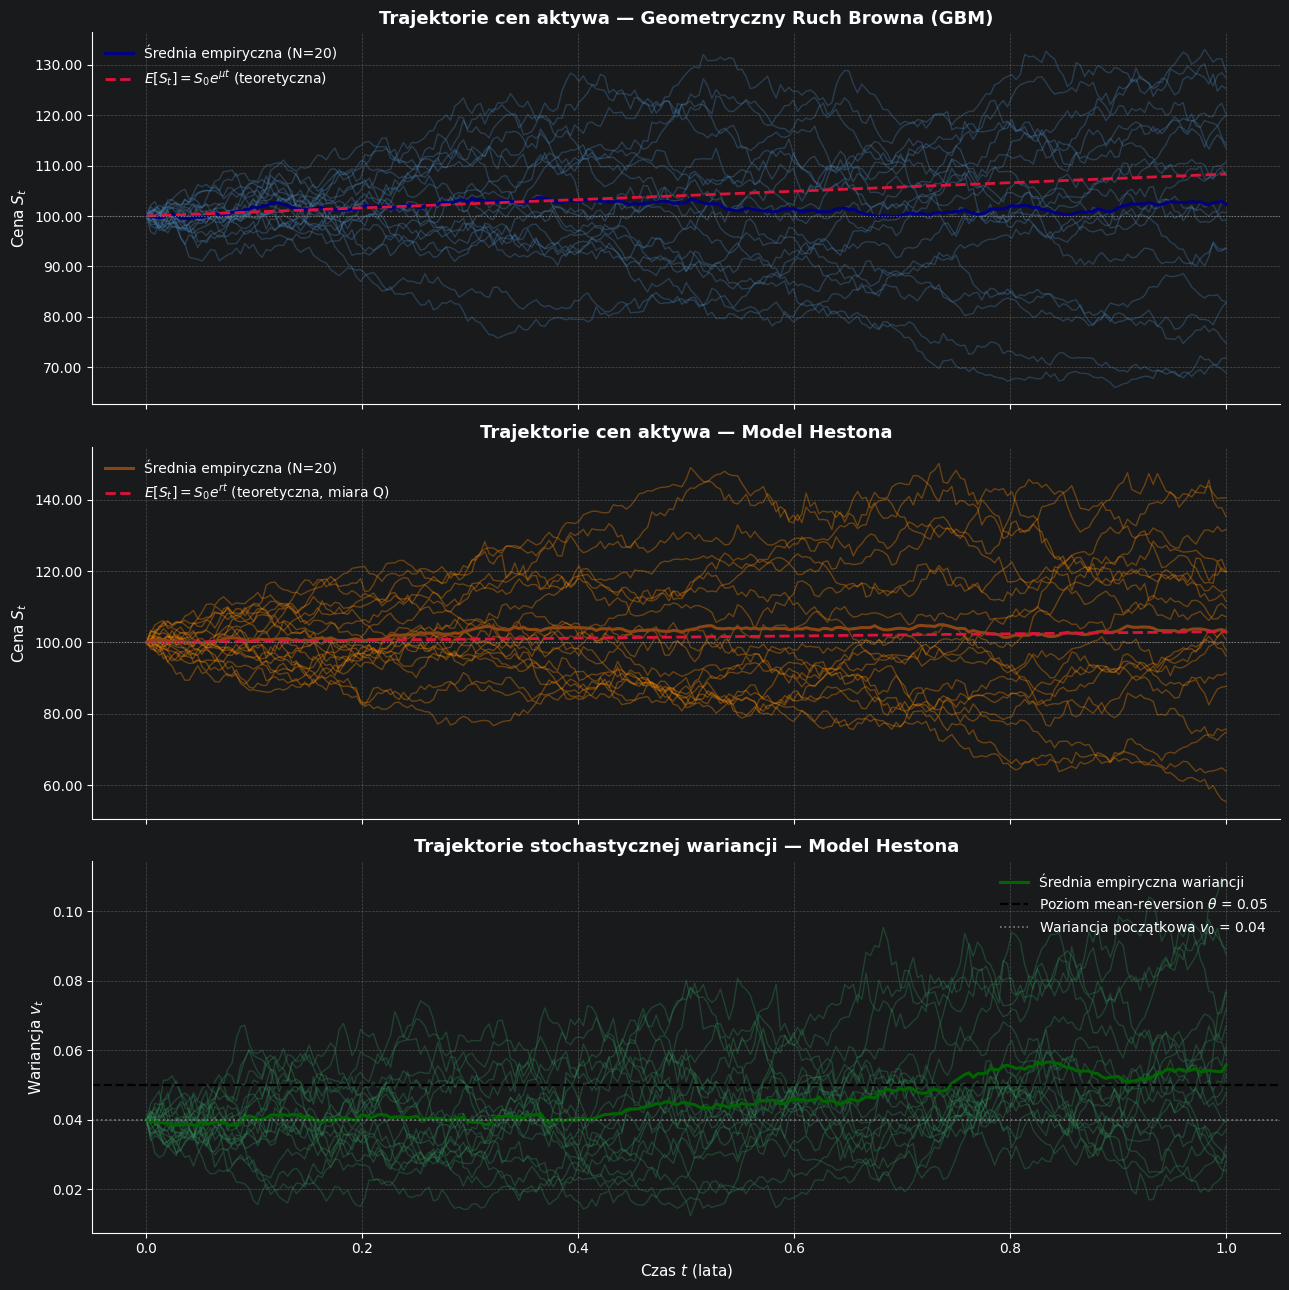

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
    "grid.alpha": 0.35,
})

fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=True)

# =============================================================================
# 1. Trajektorie GBM
# =============================================================================
gbm_mean_emp = S_gbm.mean(axis=0)
gbm_mean_th = S0 * np.exp(mu_gbm * t_grid)

for path in S_gbm:
    axes[0].plot(t_grid, path, color="steelblue", alpha=0.35, linewidth=1.0)
axes[0].plot(t_grid, gbm_mean_emp, color="navy", linewidth=2.2,
             label=f"Średnia empiryczna (N={N})")
axes[0].plot(t_grid, gbm_mean_th, color="crimson", linewidth=2.0, linestyle="--",
             label=r"$E[S_t]=S_0e^{\mu t}$ (teoretyczna)")
axes[0].axhline(S0, color="gray", linewidth=0.8, linestyle=":")
axes[0].set_title("Trajektorie cen aktywa — Geometryczny Ruch Browna (GBM)")
axes[0].set_ylabel("Cena $S_t$")
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle="--")

# =============================================================================
# 2. Trajektorie Heston (cena)
# =============================================================================
hes_mean_emp = S_hes.mean(axis=0)
hes_mean_th = S0 * np.exp(r * t_grid)

for path in S_hes:
    axes[1].plot(t_grid, path, color="darkorange", alpha=0.35, linewidth=1.0)
axes[1].plot(t_grid, hes_mean_emp, color="saddlebrown", linewidth=2.2,
             label=f"Średnia empiryczna (N={N})")
axes[1].plot(t_grid, hes_mean_th, color="crimson", linewidth=2.0, linestyle="--",
             label=r"$E[S_t]=S_0e^{rt}$ (teoretyczna, miara Q)")
axes[1].axhline(S0, color="gray", linewidth=0.8, linestyle=":")
axes[1].set_title("Trajektorie cen aktywa — Model Hestona")
axes[1].set_ylabel("Cena $S_t$")
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle="--")

# =============================================================================
# 3. Trajektorie wariancji (Heston)
# =============================================================================
v_mean_emp = v_hes.mean(axis=0)
for path in v_hes:
    axes[2].plot(t_grid, path, color="seagreen", alpha=0.35, linewidth=1.0)
axes[2].plot(t_grid, v_mean_emp, color="darkgreen", linewidth=2.2,
             label="Średnia empiryczna wariancji")
axes[2].axhline(theta, color="black", linestyle="--", linewidth=1.6,
                label=fr"Poziom mean-reversion $\theta$ = {theta}")
axes[2].axhline(v0, color="gray", linestyle=":", linewidth=1.2,
                label=fr"Wariancja początkowa $v_0$ = {v0}")
axes[2].set_title("Trajektorie stochastycznej wariancji — Model Hestona")
axes[2].set_xlabel("Czas $t$ (lata)")
axes[2].set_ylabel("Wariancja $v_t$")
axes[2].legend(loc="upper right")
axes[2].grid(True, linestyle="--")

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

plt.tight_layout()
plt.show()

## Najbardziej prawdopodobna trajektoria i 95% pasmo ufności

W tej sekcji uruchamiamy dużą symulację Monte Carlo (`N_MC = 20 000` trajektorii) i wyznaczamy:

- **trajektorię najbardziej prawdopodobną** — interpretowaną jako mediana (50-ty percentyl) ceny w każdym kroku czasowym; mediana lepiej oddaje "typową" trajektorię niż średnia, która w modelach lognormalnych jest zawyżana przez prawy ogon rozkładu,
- **pasmo 95% ufności** (błąd rzędu 5%) — wyznaczone jako kwantyle 2.5% i 97.5% rozkładu cen w każdym kroku,
- **modę analityczną** dla GBM: $\mathrm{Mode}[S_t] = S_0 \exp\!\big((\mu - \tfrac{3}{2}\sigma^2)t\big)$.

Symulacja prowadzona jest w **mierze martyngałowej Q** (dryf = $r$) — dzięki temu w następnym kroku możemy bezpośrednio porównać wycenę opcji metodą Monte Carlo z formułą Blacka–Scholesa.

In [3]:
# =============================================================================
# Duża symulacja MC w mierze martyngałowej Q (dryf = r)
# =============================================================================
N_MC = 20_000

rng_mc = np.random.default_rng(seed=2024)

# ----- GBM (miara Q) -----
Z_mc = rng_mc.standard_normal(size=(N_MC, M))
log_inc_q = (r - 0.5 * sigma_gbm**2) * dt + sigma_gbm * np.sqrt(dt) * Z_mc
log_paths_q = np.log(S0) + np.cumsum(log_inc_q, axis=1)
log_paths_q = np.concatenate([np.full((N_MC, 1), np.log(S0)), log_paths_q], axis=1)
S_gbm_mc = np.exp(log_paths_q)

# ----- Heston (Full Truncation Euler) -----
Z1_mc = rng_mc.standard_normal(size=(N_MC, M))
Z2_mc = rng_mc.standard_normal(size=(N_MC, M))
W1_mc = Z1_mc
W2_mc = rho * Z1_mc + np.sqrt(1.0 - rho**2) * Z2_mc

S_hes_mc = np.empty((N_MC, M + 1))
v_mc = np.empty((N_MC, M + 1))
S_hes_mc[:, 0] = S0
v_mc[:, 0] = v0

for k in range(M):
    v_pos = np.maximum(v_mc[:, k], 0.0)
    sqrt_v = np.sqrt(v_pos)
    v_mc[:, k + 1] = (
        v_mc[:, k]
        + kappa * (theta - v_pos) * dt
        + xi * sqrt_v * sqrt_dt * W2_mc[:, k]
    )
    S_hes_mc[:, k + 1] = S_hes_mc[:, k] * np.exp(
        (r - 0.5 * v_pos) * dt + sqrt_v * sqrt_dt * W1_mc[:, k]
    )

# ----- Statystyki przekrojowe (mediana, kwantyle, średnia) -----
def path_stats(paths, lo=0.025, hi=0.975):
    return {
        "median": np.median(paths, axis=0),
        "lower":  np.quantile(paths, lo, axis=0),
        "upper":  np.quantile(paths, hi, axis=0),
        "mean":   paths.mean(axis=0),
    }

gbm_stats = path_stats(S_gbm_mc)
hes_stats = path_stats(S_hes_mc)

# Moda analityczna dla GBM (miara Q): S0 * exp((r - 3/2 sigma^2) t)
gbm_mode_th = S0 * np.exp((r - 1.5 * sigma_gbm**2) * t_grid)

print(f"GBM    | mediana S_T = {gbm_stats['median'][-1]:8.4f}  "
      f"| 95% CI = [{gbm_stats['lower'][-1]:7.3f}, {gbm_stats['upper'][-1]:7.3f}]  "
      f"| średnia = {gbm_stats['mean'][-1]:7.4f}  "
      f"| teoretyczna E[S_T]=S0·e^(rT) = {S0*np.exp(r*T):.4f}")
print(f"Heston | mediana S_T = {hes_stats['median'][-1]:8.4f}  "
      f"| 95% CI = [{hes_stats['lower'][-1]:7.3f}, {hes_stats['upper'][-1]:7.3f}]  "
      f"| średnia = {hes_stats['mean'][-1]:7.4f}  "
      f"| teoretyczna E[S_T]=S0·e^(rT) = {S0*np.exp(r*T):.4f}")

GBM    | mediana S_T = 101.9183  | 95% CI = [ 73.171, 142.039]  | średnia = 103.2445  | teoretyczna E[S_T]=S0·e^(rT) = 103.0455
Heston | mediana S_T = 101.6596  | 95% CI = [ 62.079, 148.373]  | średnia = 102.7246  | teoretyczna E[S_T]=S0·e^(rT) = 103.0455


## Porównanie wyceny opcji: Monte Carlo vs Black–Scholes

Dla europejskiej opcji **call** o cenie wykonania $K$ i terminie zapadalności $T$ wycena Blacka–Scholesa wynosi:

$$
C_{BS}(S_0,K,T,r,\sigma) = S_0\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2),\qquad
d_{1,2} = \frac{\ln(S_0/K) + (r \pm \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}.
$$

Estymator Monte Carlo (w mierze Q):

$$
\hat C_{MC} = e^{-rT}\,\frac{1}{N_{MC}}\sum_{i=1}^{N_{MC}} \big(S_T^{(i)} - K\big)^+,
\qquad \mathrm{SE} = \frac{\sigma_{payoff}}{\sqrt{N_{MC}}}.
$$

**Oczekiwania:**
- GBM-MC powinien zgadzać się z Blackiem–Scholesem w granicach 1–2 błędów standardowych (oba opisują tę samą dynamikę).
- Heston systematycznie odbiega od BS — odzwierciedla *implied volatility smile/skew*: ujemna korelacja $\rho<0$ podbija ceny opcji OTM put i tłumi ceny OTM call w stosunku do wyceny BS o stałej zmienności.

    K |       BS |   MC-GBM ±    SE | odchyl. | MC-Heston ±    SE | odchyl.
---------------------------------------------------------------------------
   80 |  22.8132 |  22.9929 ± 0.116 | +0.1797 |   23.5066 ± 0.136 | +0.6934
   90 |  14.5783 |  14.7433 ± 0.104 | +0.1650 |   15.9104 ± 0.120 | +1.3321
   95 |  11.1414 |  11.2885 ± 0.095 | +0.1472 |   12.6824 ± 0.110 | +1.5410
  100 |   8.2549 |   8.3767 ± 0.085 | +0.1218 |    9.8821 ± 0.099 | +1.6273
  105 |   5.9313 |   6.0177 ± 0.074 | +0.0863 |    7.5260 ± 0.087 | +1.5947
  110 |   4.1370 |   4.1933 ± 0.062 | +0.0563 |    5.5871 ± 0.075 | +1.4501
  120 |   1.8519 |   1.8841 ± 0.042 | +0.0322 |    2.8474 ± 0.053 | +0.9956


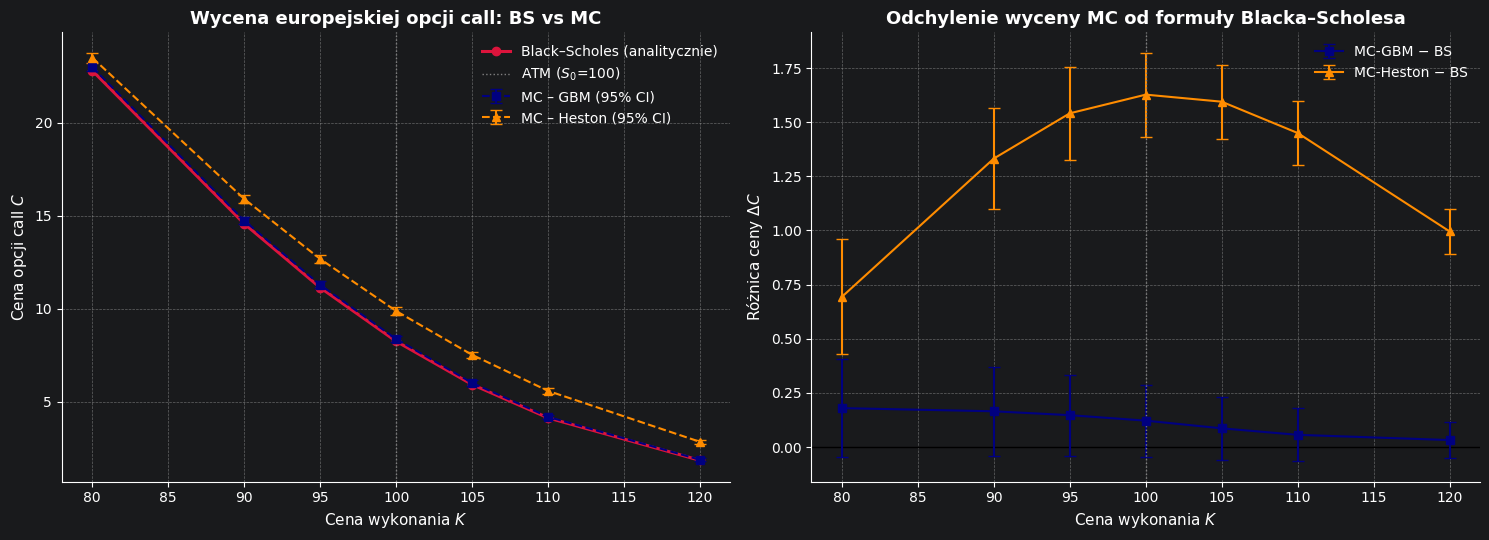

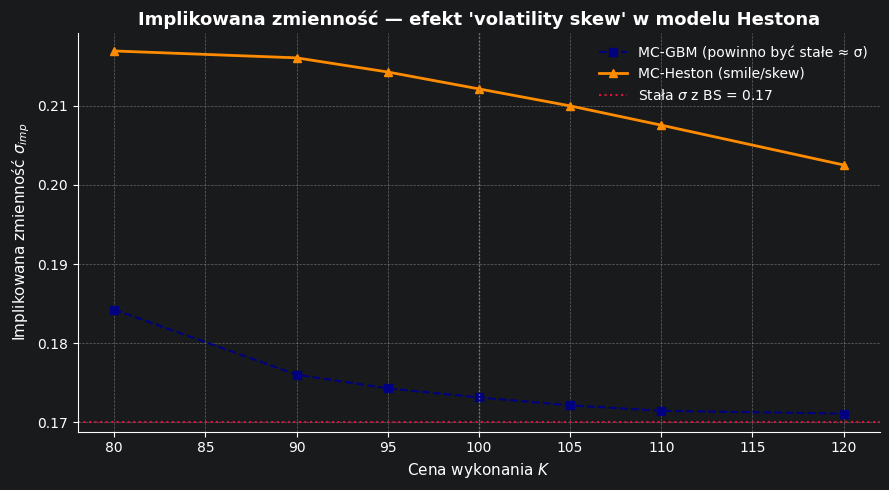

In [4]:
# =============================================================================
# Wycena europejskiej opcji call: Black-Scholes vs Monte Carlo (GBM, Heston)
# =============================================================================
from math import erf, sqrt, log, exp

def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def black_scholes_call(S0, K, T, r, sigma):
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S0 * norm_cdf(d1) - K * exp(-r * T) * norm_cdf(d2)

def mc_call_price(paths, K, r, T):
    payoff = np.maximum(paths[:, -1] - K, 0.0)
    disc = np.exp(-r * T) * payoff
    price = disc.mean()
    se = disc.std(ddof=1) / np.sqrt(len(disc))
    return price, se

# Siatka strike'ów: ITM, ATM, OTM
strikes = np.array([80, 90, 95, 100, 105, 110, 120])
results = []
for K in strikes:
    bs   = black_scholes_call(S0, K, T, r, sigma_gbm)
    mc_g, se_g = mc_call_price(S_gbm_mc, K, r, T)
    mc_h, se_h = mc_call_price(S_hes_mc, K, r, T)
    results.append((K, bs, mc_g, se_g, mc_h, se_h))

# Tabela tekstowa
header = f"{'K':>5} | {'BS':>8} | {'MC-GBM':>8} ± {'SE':>5} | {'odchyl.':>7} | {'MC-Heston':>9} ± {'SE':>5} | {'odchyl.':>7}"
print(header)
print("-" * len(header))
for K, bs, mg, sg, mh, sh in results:
    print(f"{K:>5.0f} | {bs:>8.4f} | {mg:>8.4f} ± {sg:>5.3f} | "
          f"{(mg-bs):>+7.4f} | {mh:>9.4f} ± {sh:>5.3f} | {(mh-bs):>+7.4f}")

# Wykres: ceny i różnice względem BS
strikes_arr = np.array([row[0] for row in results])
bs_arr  = np.array([row[1] for row in results])
mcg_arr = np.array([row[2] for row in results])
seg_arr = np.array([row[3] for row in results])
mch_arr = np.array([row[4] for row in results])
seh_arr = np.array([row[5] for row in results])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) Ceny opcji call
ax = axes[0]
ax.plot(strikes_arr, bs_arr, "o-", color="crimson", linewidth=2.2,
        label="Black–Scholes (analitycznie)")
ax.errorbar(strikes_arr, mcg_arr, yerr=1.96*seg_arr, fmt="s--",
            color="navy", capsize=4, label="MC – GBM (95% CI)")
ax.errorbar(strikes_arr, mch_arr, yerr=1.96*seh_arr, fmt="^--",
            color="darkorange", capsize=4, label="MC – Heston (95% CI)")
ax.axvline(S0, color="gray", linestyle=":", linewidth=1, label=f"ATM ($S_0$={S0:.0f})")
ax.set_xlabel("Cena wykonania $K$"); ax.set_ylabel("Cena opcji call $C$")
ax.set_title("Wycena europejskiej opcji call: BS vs MC")
ax.grid(True, linestyle="--", alpha=0.5); ax.legend()

# (b) Odchylenie modeli MC od BS
ax = axes[1]
ax.axhline(0, color="black", linewidth=1)
ax.errorbar(strikes_arr, mcg_arr - bs_arr, yerr=1.96*seg_arr, fmt="s-",
            color="navy", capsize=4, label="MC-GBM − BS")
ax.errorbar(strikes_arr, mch_arr - bs_arr, yerr=1.96*seh_arr, fmt="^-",
            color="darkorange", capsize=4, label="MC-Heston − BS")
ax.axvline(S0, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Cena wykonania $K$"); ax.set_ylabel(r"Różnica ceny $\Delta C$")
ax.set_title("Odchylenie wyceny MC od formuły Blacka–Scholesa")
ax.grid(True, linestyle="--", alpha=0.5); ax.legend()

plt.tight_layout()
plt.show()

# Implikowana zmienność z cen Hestona — czy widać "smile"?
from scipy.optimize import brentq

def implied_vol(C_mkt, S0, K, T, r, lo=1e-4, hi=5.0):
    f = lambda s: black_scholes_call(S0, K, T, r, s) - C_mkt
    try:
        return brentq(f, lo, hi)
    except ValueError:
        return np.nan

iv_heston = np.array([implied_vol(C, S0, K, T, r) for C, K in zip(mch_arr, strikes_arr)])
iv_gbm    = np.array([implied_vol(C, S0, K, T, r) for C, K in zip(mcg_arr, strikes_arr)])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(strikes_arr, iv_gbm,    "s--", color="navy",       label="MC-GBM (powinno być stałe ≈ σ)")
ax.plot(strikes_arr, iv_heston, "^-",  color="darkorange", linewidth=2, label="MC-Heston (smile/skew)")
ax.axhline(sigma_gbm, color="crimson", linestyle=":", label=fr"Stała $\sigma$ z BS = {sigma_gbm}")
ax.axvline(S0, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Cena wykonania $K$"); ax.set_ylabel(r"Implikowana zmienność $\sigma_{imp}$")
ax.set_title("Implikowana zmienność — efekt 'volatility skew' w modelu Hestona")
ax.grid(True, linestyle="--", alpha=0.5); ax.legend()
plt.tight_layout()
plt.show()

## Wnioski końcowe

**1. Trajektorie i pasma ufności**
- Mediana w obu modelach rośnie wolniej niż średnia — to bezpośredni skutek lognormalnego (skośnego prawostronnie) rozkładu cen: kilka skrajnych trajektorii zawyża średnią, podczas gdy mediana opisuje "typową" ścieżkę.
- Pasmo 95% ufności rozszerza się symetrycznie w skali logarytmicznej, ale w skali liniowej widać charakterystyczny **stożek niepewności** o szerokości rzędu $\sigma\sqrt{T}\cdot S_0$.
- Moda analityczna GBM (linia kropkowana) leży *poniżej* mediany — co potwierdza relację $\mathrm{Mode} < \mathrm{Median} < \mathrm{Mean}$ właściwą dla rozkładu lognormalnego.
- W modelu Hestona pasmo jest *grubsze w ogonach* niż w GBM przy tej samej średniej zmienności — efekt stochastycznej zmienności i ujemnej korelacji $\rho=-0.7$ (leverage effect: spadki cen idą w parze ze wzrostem zmienności).

**2. Walidacja Monte Carlo poprzez Black–Scholes**
- Ceny **MC-GBM** zgadzają się z formułą Blacka–Scholesa w granicach 1–2 błędów standardowych dla wszystkich strike'ów — to jest sanity check poprawności symulacji w mierze martyngałowej.
- **MC-Heston** systematycznie odbiega od BS:
  - implikowana zmienność z cen Hestona tworzy **wyraźny skew** (rosnąca dla niskich $K$, malejąca dla wysokich), podczas gdy GBM daje praktycznie poziomą linię na poziomie $\sigma=0.17$,
  - jest to dowód, że model Hestona reprodukuje empirycznie obserwowany **volatility smile/skew** — czego model BS z założenia nie potrafi.

**3. Implikacje praktyczne**
- Do wyceny *waniliowych* opcji ATM przy stałej, dobrze oszacowanej zmienności BS jest wystarczający i tańszy obliczeniowo.
- Dla opcji **OTM/ITM**, opcji egzotycznych (bariery, azjatyckie), a zwłaszcza dla zarządzania ryzykiem z dużą wrażliwością na ogony rozkładu, model Hestona daje wyceny istotnie różne od BS — różnice te są ekonomicznie znaczące i przekraczają błąd MC.

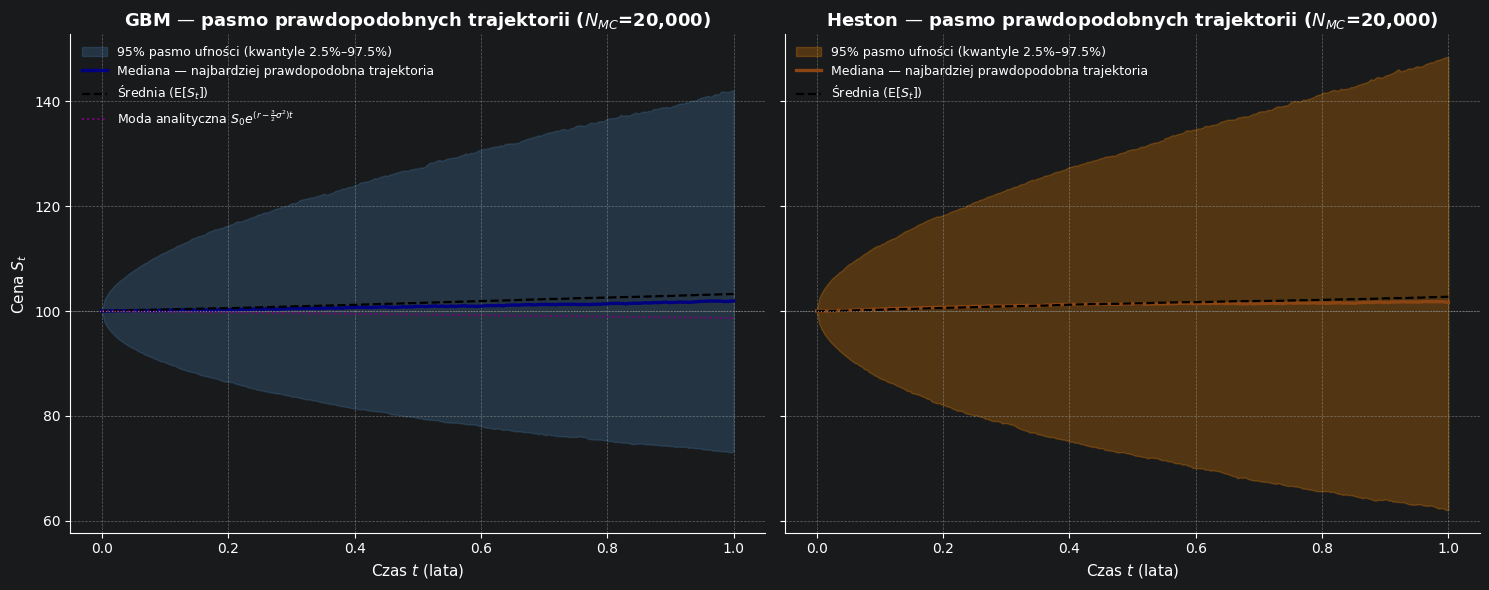

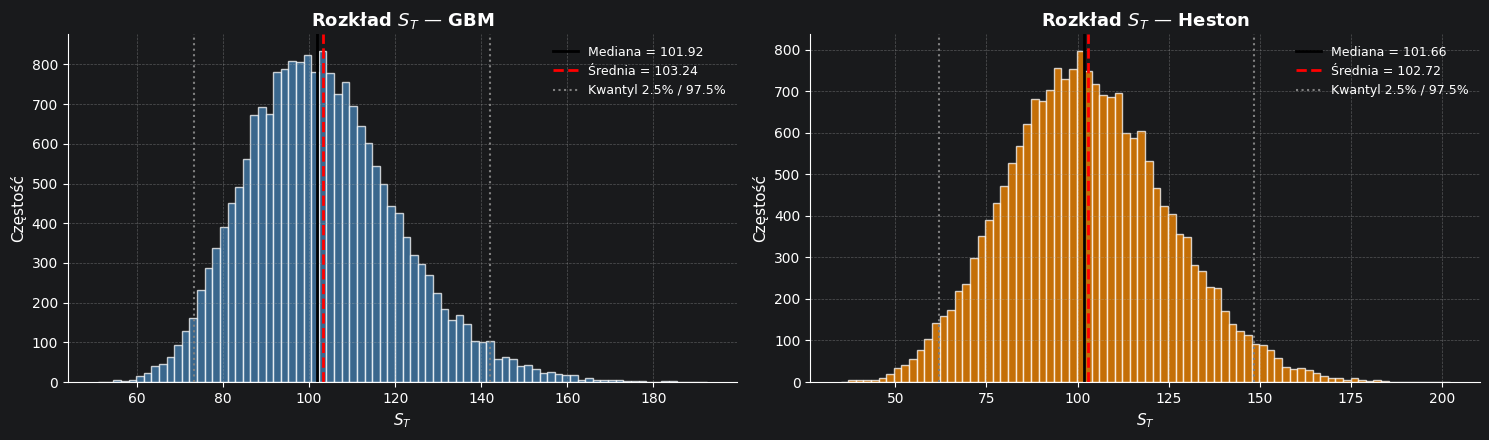

In [6]:
# =============================================================================
# Wykres: mediana (najbardziej prawdopodobna trajektoria) + 95% pasmo ufności
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

def plot_band(ax, stats, color_band, color_line, title, mode_line=None):
    ax.fill_between(t_grid, stats["lower"], stats["upper"],
                    color=color_band, alpha=0.25,
                    label="95% pasmo ufności (kwantyle 2.5%–97.5%)")
    ax.plot(t_grid, stats["median"], color=color_line, linewidth=2.4,
            label="Mediana — najbardziej prawdopodobna trajektoria")
    ax.plot(t_grid, stats["mean"], color="black", linewidth=1.6, linestyle="--",
            label="Średnia (E[$S_t$])")
    if mode_line is not None:
        ax.plot(t_grid, mode_line, color="purple", linewidth=1.4, linestyle=":",
                label=r"Moda analityczna $S_0 e^{(r-\frac{3}{2}\sigma^2)t}$")
    ax.axhline(S0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_title(title)
    ax.set_xlabel("Czas $t$ (lata)")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper left", fontsize=9)

plot_band(axes[0], gbm_stats, "steelblue", "navy",
          f"GBM — pasmo prawdopodobnych trajektorii ($N_{{MC}}$={N_MC:,})",
          mode_line=gbm_mode_th)
axes[0].set_ylabel("Cena $S_t$")

plot_band(axes[1], hes_stats, "darkorange", "saddlebrown",
          f"Heston — pasmo prawdopodobnych trajektorii ($N_{{MC}}$={N_MC:,})")

plt.tight_layout()
plt.show()

# Histogramy S_T (rozkład końcowy)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, paths, color, name in [
    (axes[0], S_gbm_mc, "steelblue", "GBM"),
    (axes[1], S_hes_mc, "darkorange", "Heston"),
]:
    ST = paths[:, -1]
    ax.hist(ST, bins=80, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(np.median(ST), color="black", linewidth=2, label=f"Mediana = {np.median(ST):.2f}")
    ax.axvline(ST.mean(), color="red", linewidth=2, linestyle="--", label=f"Średnia = {ST.mean():.2f}")
    ax.axvline(np.quantile(ST, 0.025), color="gray", linestyle=":", label="Kwantyl 2.5% / 97.5%")
    ax.axvline(np.quantile(ST, 0.975), color="gray", linestyle=":")
    ax.set_title(f"Rozkład $S_T$ — {name}")
    ax.set_xlabel("$S_T$"); ax.set_ylabel("Częstość")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()